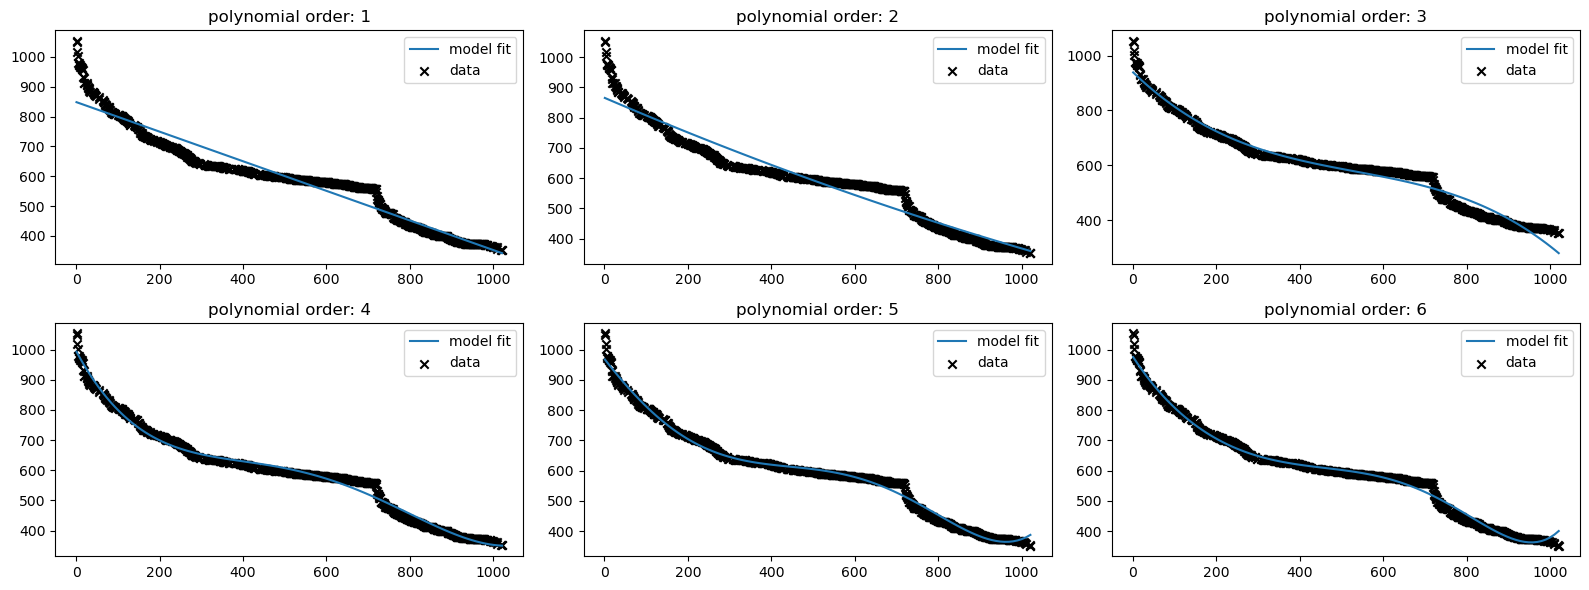

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv('Turas_Training_Data1.csv')

# Define polynomial function
def polynomial(x, coeffs):
    """ Evaluates a polynomial at the given values of x.
    
    :param x: array of values to evaluate the polynomial at
    :param coeffs: the coefficients of the polynomial, in descending order
    """
    poly = np.poly1d(coeffs)
    return poly(x)

# Fit polynomials of different orders to the data
orders = list(range(1, 7))
coefficients = {}

for order in orders:
    x = data['Journey_Number']
    y = data['Total']
    coeffs = np.polyfit(x, y, order)
    coefficients[order] = coeffs

# Plot the data and the fitted models
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(16, 6))
ax = axs.flatten()

x_plot = np.linspace(data['Journey_Number'].min(), data['Journey_Number'].max(), 100)

for i, coeffs in enumerate(coefficients.values()):
    y_plot = polynomial(x_plot, coeffs)
    ax[i].plot(x_plot, y_plot, label='model fit')
    ax[i].scatter(data['Journey_Number'], data['Total'], marker='x', color='k', label='data')
    ax[i].set_title(f'polynomial order: {list(coefficients.keys())[i]}')
    ax[i].legend()

plt.tight_layout()
plt.show()
